# 03 - PhysioNet Challenge sources: Georgia, CPSC 2018, CPSC-Extra and Chapman/Shaoxing

These four sources come from the PhysioNet/CinC Challenges 2020 and 2021. Georgia, CPSC 2018 and
CPSC-Extra enter the project's 76,598-record union dataset as **unlabeled pretraining data**;
Chapman/Shaoxing is downloaded but left out. Their diagnoses are not mapped to the project's label,
and their record IDs are not patient IDs, so none of them is used for supervised training or
evaluation.

All four share one format: WFDB headers with age, sex and SNOMED-CT diagnosis codes in comments,
and signals in `.mat` files. Everything below is read from the raw files in
`data/raw/challenge-2020/1.0.2/` and `data/raw/challenge-2021/1.0.3/`.

The PTB-XL notebook set the reference for a clean ECG and validated our noise measures; the MIMIC
notebook validated the heart-rate estimate. Here we compare four sources side by side, and check
how the project curated them into the union.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from eda.challenge import challenge_summary, load_headers, read_signal, signal_hashes, snomed_names
from eda.processed import challenge_union_reasons, compare_union, near_rail_windows
from eda.ptbxl import load_metadata
from eda.ptbxl_signals import ptbxl_summary
from eda.signals import plot_ecg, problem_counts

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

headers = load_headers()
SOURCES = ["georgia", "cpsc_2018", "cpsc_2018_extra", "chapman_shaoxing"]

## 1. Format and size

Before comparing content, confirm that the four sources store signals the same way: sampling rate,
units, gain, lead order and length.

In [3]:
formats = headers.groupby("source").agg(
    records=("record", "size"),
    sampling_rates=("fs", lambda values: sorted(values.unique())),
    units=("units", lambda values: sorted(values.unique())),
    gain=("gain", lambda values: sorted(values.unique())),
    lead_orders=("lead_names", "nunique"),
).loc[SOURCES]
display(formats)
display(headers.groupby("source")["duration_s"].describe(percentiles=[0.05, 0.5, 0.95]).loc[SOURCES].round(1))

,records,sampling_rates,units,gain,lead_orders
source,,,,,
georgia,10344,[500],[mV],[1000.0],1
cpsc_2018,6877,[500],[mV],[1000.0],1
cpsc_2018_extra,3453,[500],[mV],[1000.0],1
chapman_shaoxing,10247,[500],[mV],[1000.0],1


,count,mean,std,min,5%,50%,95%,max
source,,,,,,,,
georgia,10344.0,10.0,0.4,5.0,10.0,10.0,10.0,10.0
cpsc_2018,6877.0,15.9,10.0,6.0,10.0,12.0,35.1,144.0
cpsc_2018_extra,3453.0,15.9,9.7,8.0,10.0,12.0,37.0,98.0
chapman_shaoxing,10247.0,10.0,0.0,10.0,10.0,10.0,10.0,10.0


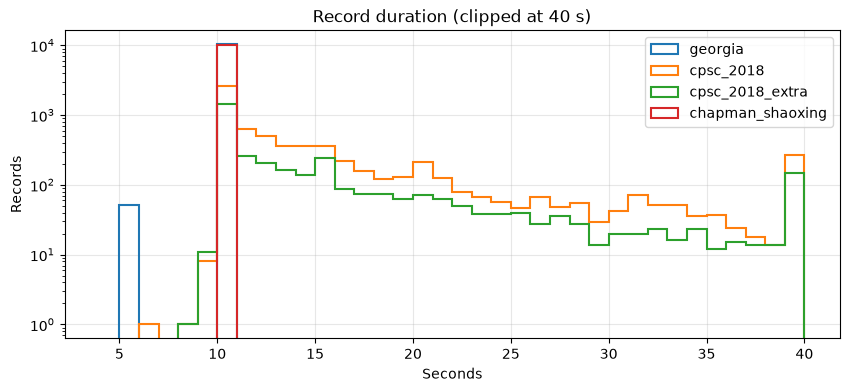

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for source in SOURCES:
    durations = headers.loc[headers["source"] == source, "duration_s"].clip(upper=40)
    ax.hist(durations, bins=np.arange(4, 41, 1), histtype="step", linewidth=1.5, label=source)
ax.set(title="Record duration (clipped at 40 s)", xlabel="Seconds", ylabel="Records", yscale="log")
ax.legend()
plt.show()

**Finding: one format, different lengths.** All 30,921 records are 500 Hz, in mV, with a gain of
1000 per mV and the standard lead order, so they can be read the same way. The difference is length.
Georgia and Chapman are ten seconds (52 Georgia records are only five), but CPSC 2018 and CPSC-Extra
range from 6 to 144 seconds, with a median of 12. The project handles this by taking ten-second
windows: an exact window when a record is ten seconds, and a centered crop otherwise. Records
shorter than ten seconds cannot be used.

A gain of 1000 per mV with 16-bit integers means the largest storable value is 32.767 mV. That
detail comes back in section 5.

## 2. Missing values and demographics

age field,-1,NaN
source,,
cpsc_2018,4,5
cpsc_2018_extra,2,1
georgia,0,77


sex,Female,Male
source,,
georgia,0.463,0.537
cpsc_2018,0.462,0.538
cpsc_2018_extra,0.466,0.534
chapman_shaoxing,0.441,0.559


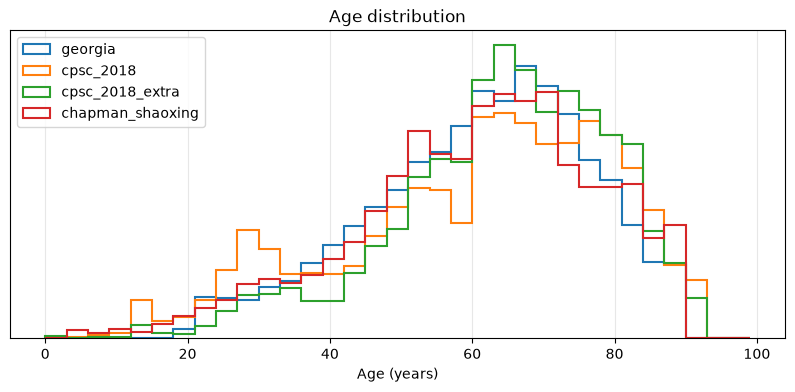

In [5]:
unusual_age = headers.loc[headers["age_years"].isna() | (headers["age_years"] < 0), "age"]
display(pd.crosstab(headers.loc[unusual_age.index, "source"], unusual_age).rename_axis(
    index="source", columns="age field"))
display(headers.groupby("source")["sex"].value_counts(normalize=True).unstack().loc[SOURCES].round(3))
fig, ax = plt.subplots(figsize=(10, 4))
for source in SOURCES:
    ages = headers.loc[(headers["source"] == source) & (headers["age_years"] >= 0), "age_years"]
    ax.hist(ages, bins=np.arange(0, 100, 3), histtype="step", density=True, linewidth=1.5, label=source)
ax.set(title="Age distribution", xlabel="Age (years)", yticks=[])
ax.legend()
plt.show()

**Finding.** Metadata is nearly complete: 83 records have `NaN` as age and 6 have `-1` (both mean
unknown), and sex is always present. All four sources are adult cardiology populations (median age
60-65) with a slight male majority, similar to PTB-XL. Georgia and Chapman cap ages at 89, CPSC
goes up to 92.

## 3. Diagnoses

Diagnoses are SNOMED-CT codes. We name them with the Challenge mapping tables shipped in
`third_party/ecg-fm-benchmarking` and look at what each source contains.

In [6]:
names = snomed_names()
codes = headers.explode("dx_codes")
unmapped = sorted(set(codes["dx_codes"]) - set(names))
print(f"Distinct codes: {codes['dx_codes'].nunique()}; without a name in the mapping: {unmapped}")
per_source = codes.groupby("source")["dx_codes"].value_counts().groupby(level=0).head(8).rename("records")
per_source = per_source.reset_index()
per_source["diagnosis"] = per_source["dx_codes"].map(names)
for source in SOURCES:
    table = per_source[per_source["source"] == source][["diagnosis", "dx_codes", "records"]]
    display(table.set_index("diagnosis").rename_axis(source))

Distinct codes: 103; without a name in the mapping: ['251199005']


,dx_codes,records
georgia,,
t wave abnormal,164934002,2306
nonspecific st t abnormality,428750005,1883
sinus rhythm,426783006,1752
sinus bradycardia,426177001,1677
prolonged qt interval,111975006,1391
sinus tachycardia,427084000,1261
premature atrial contraction,284470004,1236
left ventricular hypertrophy,164873001,1233


,dx_codes,records
cpsc_2018,,
right bundle branch block,59118001,1857
atrial fibrillation,164889003,1221
sinus rhythm,426783006,918
st depression,429622005,869
1st degree av block,270492004,722
premature ventricular complexes,164884008,700
premature atrial contraction,284470004,616
left bundle branch block,164909002,236


,dx_codes,records
cpsc_2018_extra,,
nonspecific st t abnormality,428750005,1293
old myocardial infarction,164867002,1168
st interval abnormal,164930006,481
myocardial ischemia,164861001,384
myocardial infarction,164865005,376
sinus tachycardia,427084000,303
bradycardia,426627000,271
premature ventricular contractions,427172004,188


,dx_codes,records
chapman_shaoxing,,
sinus bradycardia,426177001,3889
t wave abnormal,164934002,1876
sinus rhythm,426783006,1826
atrial fibrillation,164889003,1780
sinus tachycardia,427084000,1568
LVHV,55827005,1295
nonspecific st t abnormality,428750005,1158
supraventricular tachycardia,426761007,587


In [7]:
headers["sinus_rhythm_only"] = headers["dx_codes"].apply(lambda listed: listed == ["426783006"])
headers["codes"] = headers["dx_codes"].apply(len)
display(headers.groupby("source").agg(codes_per_record=("codes", "mean"),
                                      sinus_rhythm_only=("sinus_rhythm_only", "mean")).loc[SOURCES].round(3))

,codes_per_record,sinus_rhythm_only
source,,
georgia,2.331,0.169
cpsc_2018,1.070,0.133
cpsc_2018_extra,1.755,0.000
chapman_shaoxing,1.839,0.133


**Finding: four different case mixes, and "normal" is rare.**

- **CPSC 2018** has nine diagnosis classes (the original challenge task). It is dominated by
  arrhythmias and conduction defects: right bundle branch block, atrial fibrillation, PVCs,
  first-degree AV block.
- **CPSC-Extra** holds the remaining CPSC recordings, mostly ischemic and infarct findings. None of
  its records is sinus rhythm only.
- **Georgia** is broad: T-wave abnormalities, ST changes, sinus brady- and tachycardia.
- **Chapman/Shaoxing** is rhythm-oriented: sinus bradycardia is its most common label.

Only 0-17% of records per source are plain sinus rhythm. These cohorts are much more abnormal than
PTB-XL (where 42% of records are NORM only), which is fine for pretraining but means their label distributions
are not comparable. One code (251199005) has no name in the mapping.

## 4. Duplicate recordings

The Challenge organizers assembled these sources from several releases, and CPSC-Extra comes from
the same hospital as CPSC 2018. We hash every record's samples (at the 1 microvolt storage
resolution) to find exact duplicates.

In [8]:
headers["hash"] = signal_hashes(headers)
duplicated = headers[headers["hash"].duplicated(keep=False)]
groups = duplicated.groupby("hash").agg(sources=("source", lambda values: " + ".join(sorted(values))),
                                         diagnoses=("dx", "nunique"))
display(pd.Series({"records that have an exact copy": len(duplicated),
                   "duplicate groups": len(groups),
                   "groups whose copies carry different diagnoses": int((groups["diagnoses"] > 1).sum())})
        .to_frame("count"))
display(groups["sources"].value_counts().head(8).to_frame("groups"))

,count
records that have an exact copy,1508
duplicate groups,742
groups whose copies carry different diagnoses,344


,groups
sources,
cpsc_2018 + cpsc_2018_extra,319
cpsc_2018 + cpsc_2018,238
georgia + georgia,90
cpsc_2018_extra + cpsc_2018_extra,60
chapman_shaoxing + chapman_shaoxing,13
cpsc_2018 + cpsc_2018 + cpsc_2018_extra,8
cpsc_2018 + cpsc_2018_extra + cpsc_2018_extra,7
georgia + georgia + georgia,2


**Finding: 1,508 records (5%) are exact copies of another record, and many disagree on the
diagnosis.** Most duplicates pair a CPSC 2018 record with a CPSC-Extra record, or two records inside
CPSC 2018. In 344 of the 742 groups, the identical signal carries different diagnosis codes. For
pretraining, duplicates only waste compute. But anyone who later uses these labels must deduplicate
first, or the same ECG ends up on both sides of a split with conflicting labels. Section 6 checks that
the project removed them from the union.

## 5. Signal integrity

All 30,921 records through the same checks as PTB-XL and MIMIC (about 5 minutes, then cached).

In [9]:
summary = challenge_summary(headers)
display(summary.groupby("source").apply(problem_counts).loc[SOURCES].T)

source,georgia,cpsc_2018,cpsc_2018_extra,chapman_shaoxing
records,10344,6877,3453,10247
any_nan,6,0,0,0
fully_constant_lead,9,18,8,15
lead_flat_for_1s,12,59,30,17
lead_over_10mv,18,99,55,22
limb_identity_violated,1,62,29,0
heart_rate_not_estimated,0,0,2,0


,peak_abs_mv,einthoven_residual,avf_residual,avl_residual,avr_residual
source,,,,,
cpsc_2018,32.755,32.741,0.002,32.741,65.482
cpsc_2018_extra,32.767,32.757,0.002,32.756,65.518
georgia,32.767,32.968,22.704,21.830,32.767


,records
records reaching 32.6 mV or more,83
... of which violate a limb identity,80
limb violations without saturation,12


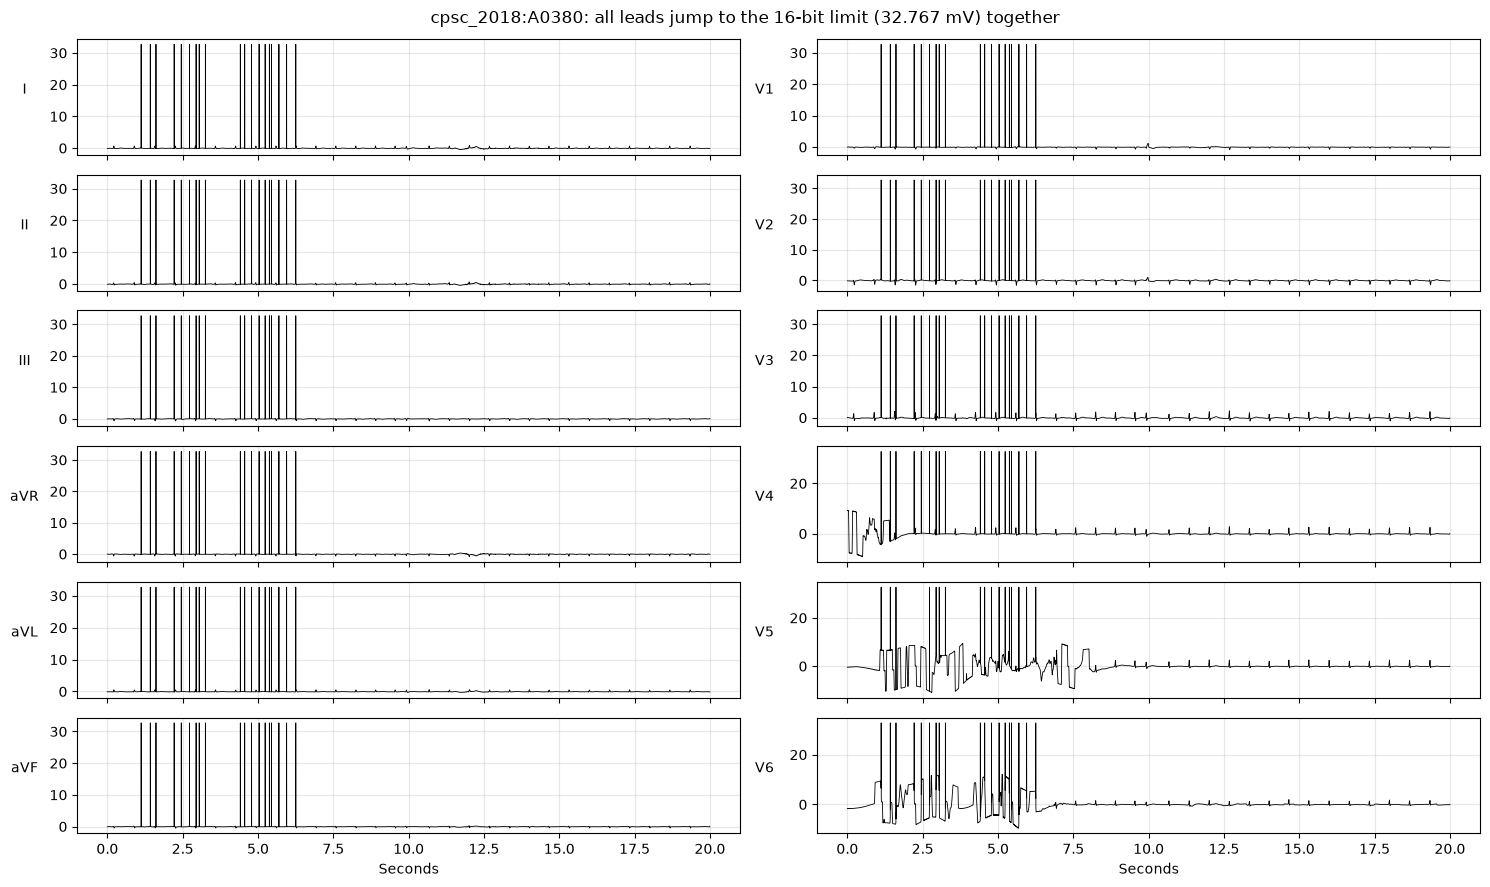

In [10]:
limb = summary[["einthoven_residual", "avf_residual", "avl_residual", "avr_residual"]].max(axis=1)
violated = summary[limb > 0.05]
display(violated.groupby("source")[["peak_abs_mv", "einthoven_residual", "avf_residual",
                                     "avl_residual", "avr_residual"]].median().round(3))
saturated = summary[summary["peak_abs_mv"] >= 32.6]
display(pd.Series({"records reaching 32.6 mV or more": len(saturated),
                   "... of which violate a limb identity": int((limb[saturated.index] > 0.05).sum()),
                   "limb violations without saturation":
                       int(((limb > 0.05) & (summary["peak_abs_mv"] < 32.6)).sum())})
        .to_frame("records"))
typical = saturated[(saturated["source"] == "cpsc_2018") & (saturated["avf_residual"] < 0.01)]
example = typical.index[0]
signal, fs = read_signal(f"cpsc_2018:{headers.loc[example, 'path']}")
plot_ecg(signal, fs, f"{example}: all leads jump to the 16-bit limit (32.767 mV) together", seconds=20)
plt.show()

**Finding: the limb-lead violations are storage artifacts, not lead swaps.** Unlike MIMIC, the
CPSC violations are huge, and 80 of the 92 violating records reach the 32.767 mV storage limit. The
residual pattern explains what happens: Einthoven about 32.7 mV, aVR about 65.5 mV, aVF about 0. That
is exactly what you get when **all twelve leads are set to +32.767 mV at the same instant**, as in the
example above: a handful of samples (median 3-6) where every lead jumps to the maximum value. In 76%
of affected CPSC 2018 records and 97% of CPSC-Extra records, every rail value is simultaneous across
leads. This is a storage or export artifact rather than an amplifier saturating. The 4 Georgia
records are genuine single-lead saturation. Chapman has none. The other problems are small: 50
records with a constant lead across the four sources, 6 Georgia records with NaN samples, and 12
minor limb inconsistencies.

## 6. Signal distributions compared with PTB-XL

,peak_abs_mv,std,baseline_fraction,high_frequency_fraction,powerline_50_fraction,heart_rate
source,,,,,,
ptbxl,1.905,0.152,0.020,0.007,7.000e-04,71.259
georgia,1.654,0.143,0.024,0.008,8.000e-04,75.282
cpsc_2018,2.083,0.149,0.006,0.005,5.000e-04,76.923
cpsc_2018_extra,2.060,0.143,0.006,0.005,5.000e-04,76.628
chapman_shaoxing,2.230,0.151,0.023,0.012,1.200e-03,73.529


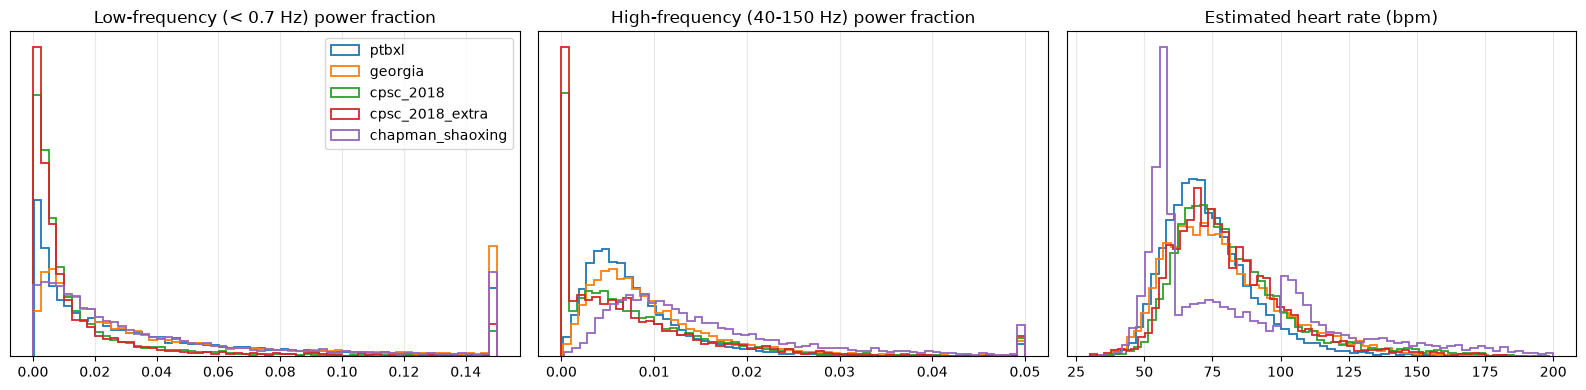

In [11]:
ptbxl = ptbxl_summary(load_metadata()).assign(source="ptbxl")
metrics = ["peak_abs_mv", "std", "baseline_fraction", "high_frequency_fraction",
           "powerline_50_fraction", "heart_rate"]
combined = pd.concat([ptbxl[["source", *metrics]], summary[["source", *metrics]]])
display(combined.groupby("source")[metrics].median().loc[["ptbxl", *SOURCES]].round(4))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
style = {"bins": 60, "density": True, "histtype": "step", "linewidth": 1.3}
for source in ["ptbxl", *SOURCES]:
    values = combined[combined["source"] == source]
    axes[0].hist(values["baseline_fraction"].clip(upper=0.15), label=source, **style)
    axes[1].hist(values["high_frequency_fraction"].clip(upper=0.05), label=source, **style)
    axes[2].hist(values["heart_rate"].clip(30, 200), label=source, **style)
titles = ["Low-frequency (< 0.7 Hz) power fraction", "High-frequency (40-150 Hz) power fraction",
          "Estimated heart rate (bpm)"]
for axis, title in zip(axes, titles, strict=True):
    axis.set(title=title, yticks=[])
axes[0].legend()
plt.tight_layout()
plt.show()

**Finding: the two CPSC sources were heavily filtered; Chapman is the noisiest.** CPSC 2018 and
CPSC-Extra have about 3x less low-frequency power and less high-frequency power than PTB-XL. Their
signals were band-pass filtered before release, and the two sources are nearly indistinguishable from
each other, as expected for recordings from the same hospital. Chapman has the most high-frequency
content, about twice PTB-XL's. Georgia sits close to PTB-XL. Amplitudes and heart rates are similar
everywhere. So pooling these sources mixes at least three filtering regimes, which the cross-dataset
notebook quantifies.

## 7. Raw data versus the union dataset

The project curated Georgia, CPSC 2018 and CPSC-Extra into the union (Chapman was left out). We check
three things: that the stored windows match the raw files, that every raw record missing from the
union has a reason we can reproduce, and that no clipped samples slipped through.

In [12]:
union = compare_union(per_source=40)
challenge_rows = union[union["source"].isin(SOURCES)]
display(challenge_rows.groupby(["source", "view"])["max_abs_difference_mv"].agg(["count", "max"]))
reasons = challenge_union_reasons(headers, summary, headers["hash"])
display(pd.crosstab(headers.loc[reasons.index, "source"], reasons, margins=True))

count        max
source          view                                  
cpsc_2018       cpsc_ssl_center_crop     25  4.730e-07
                strict_10s               15  2.365e-07
cpsc_2018_extra cpsc_ssl_center_crop     30  2.365e-07
                strict_10s               10  2.365e-07
georgia         strict_10s               40  1.183e-07

col_0,NaN samples,clipped at the 16-bit rail,constant lead,exact duplicate of a kept record,shorter than 10 s,All
source,,,,,,
cpsc_2018,0,14,18,254,10,296
cpsc_2018_extra,0,12,8,400,12,432
georgia,6,0,9,90,52,157
All,6,26,35,744,74,885


In [13]:
clipped = near_rail_windows()
display(pd.Series({"union windows with samples at 32.6 mV or more": len(clipped),
                   "... that contain the exact 32.767 mV value": int(clipped["exact_rail"].sum()),
                   "median clipped samples per window": clipped["clipped_samples"].median()})
        .to_frame("value"))
display(clipped.groupby(["source", "view"]).size().to_frame("windows"))

,value
union windows with samples at 32.6 mV or more,29.0
... that contain the exact 32.767 mV value,0.0
median clipped samples per window,84.0


windows
source          view                         
cpsc_2018       cpsc_ssl_center_crop       21
                strict_10s                  2
cpsc_2018_extra cpsc_ssl_center_crop        5
                strict_10s                  1

**Finding: the curation is right, with one gap.**

- Stored windows match the raw files to float32 rounding, and centered crops are taken from the
  right place.
- Every one of the 885 raw records missing from the union has a reason we reproduce independently:
  744 exact duplicates of a record that was kept, 74 records shorter than ten seconds, 35 with a
  constant lead, 26 clipped at the rail, and 6 with NaN samples. No duplicates remain.
- **Gap:** the project's clipping rule only matches the exact values +32.767 and -32.768 mV. Clipped
  stretches often sit just below the rail (32.69-32.76 mV) instead, so **29 union windows still
  contain near-rail plateaus** (a median of about 80 samples each, none with the exact value). It is a
  small number, but a threshold rule such as |x| >= 32.6 mV would catch them all.
- **Chapman/Shaoxing** was left out as "incomplete", but on our checks it is the cleanest of the four:
  every record is ten seconds, there is no clipping, no NaN and no limb violation, and only 15 records
  have a constant lead. It could add about 10,000 recordings to pretraining after deduplication.

## 8. Conclusions

**What is correct**

- All four sources are read correctly (same format, units and lead order), and the union windows
  match the raw files exactly.
- The union excludes exactly the records it should: short records, exact duplicates, NaNs, rail
  hits and constant leads. We can reproduce every exclusion.

**What needs attention**

1. **Clipping below the exact rail is missed.** 29 union windows contain clipped plateaus.
   *Recommendation:* use an amplitude threshold (|x| >= 32.6 mV) instead of exact-value matching.
2. **Duplicates carry conflicting diagnoses** (344 groups). This is irrelevant for pretraining, but
   essential to handle before these labels are ever used.
3. **Three filtering regimes are being pooled** (CPSC heavily filtered, Chapman noisy, Georgia close
   to PTB-XL). The source is partly identifiable from noise alone; see the cross-dataset notebook.
4. **Chapman is usable.** It is excluded, but it is clean on every check.

Next, CODE-15%, the only source whose units and duration are still unresolved.